<a href="https://colab.research.google.com/github/GITHUBTANMAY/Earthquake-Detection-Using-Machine-Learning-on-Optical-Fiber-DAS-Data/blob/main/Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
# Adjust this path based on where you put them in Drive
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy')
print("Data loaded successfully! Shape:", X_raw.shape)

Data loaded successfully! Shape: (10000, 6000, 3)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert data to PyTorch tensors
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.float32).unsqueeze(1)

# 2. Create DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 3. Define the CNN architecture
class SeismicCNN(nn.Module):
    def __init__(self):
        super(SeismicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.features(x)
        return self.classifier(torch.flatten(x, 1))

model = SeismicCNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop
print("Starting training...")
model.train()
for epoch in range(10): # Let's train for 10 epochs
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

print("Training Complete!")

Starting training...
Epoch 1, Loss: 0.5597
Epoch 2, Loss: 0.4172
Epoch 3, Loss: 0.3774
Epoch 4, Loss: 0.3412
Epoch 5, Loss: 0.3290
Epoch 6, Loss: 0.3199
Epoch 7, Loss: 0.3029
Epoch 8, Loss: 0.2957
Epoch 9, Loss: 0.2900
Epoch 10, Loss: 0.2795
Training Complete!


In [ ]:
import torch
# Create a path in your mounted Google Drive
save_path = '/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'

# Save the model's learned parameters
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to: {save_path}")

Model weights saved to: /content/drive/MyDrive/DAS_Data/seismic_model_final.pth


In [ ]:
import torch
import torch.nn as nn

# Define the structure (must be identical to your training architecture)
class SeismicCNN(nn.Module):
    def __init__(self):
        super(SeismicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.features(x)
        return self.classifier(torch.flatten(x, 1))

# Initialize the model object
model = SeismicCNN()
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'))
model.eval()
print("Model loaded and ready for evaluation!")

Model loaded and ready for evaluation!


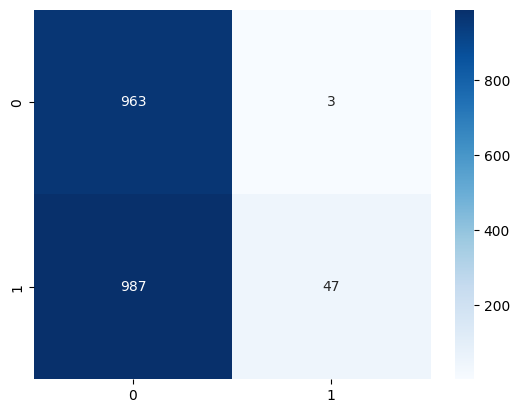

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define model architecture
class SeismicCNN(nn.Module):
    # ... [Keep your existing SeismicCNN class definition here] ...
    def __init__(self):
        super(SeismicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.classifier(torch.flatten(self.features(x), 1))

# 2. Load model
model = SeismicCNN()
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'))
model.eval()

# 3. Load and evaluate in smaller chunks to prevent RAM crash
# Instead of loading everything, we process in a loop or verify if a subset works
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r') # Use mmap to not load fully into RAM
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

# If still crashing, only evaluate on a smaller subset for the confusion matrix
subset_size = 2000
X_subset = torch.tensor(X_raw[:subset_size], dtype=torch.float32)
y_subset = torch.tensor(y_raw[:subset_size], dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    y_pred = (model(X_subset) > 0.5).float()

# 4. Plot
cm = confusion_matrix(y_subset.numpy(), y_pred.numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()